In [1]:
import torch
from torch.utils.data import Dataset
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import torch.nn as nn
from torch.nn import Transformer, TransformerEncoderLayer, TransformerDecoderLayer

In [2]:
torch.cuda.is_available()

True

# Utilities and data upload

In [3]:
class ChunkedNumpyDataset(Dataset):
    def __init__(self, input_paths, max_events=None, device=None):

        self.input_data = []

        for input_path in input_paths:
            if max_events:
                self.input_data.append(torch.from_numpy(np.load(input_path)[:max_events]).to(torch.float32))
            else:
                self.input_data.append(torch.from_numpy(np.load(input_path)).to(torch.float32))

        self.total_length = min(len(d) for d in self.input_data)
        assert all(len(d) == self.total_length for d in self.input_data), \
            "All input and target arrays must have the same length"

        if device:
            self.input_data = [data.pin_memory().to(device) for data in self.input_data]

    def __len__(self):
        return self.total_length

    def __getitem__(self, idx):

        inputs = [data[idx] for data in self.input_data]
        return inputs

def get_obj_type_tensor(max_njets):
    o = torch.zeros((max_njets+2+1+1, 1), dtype=torch.float32) # 2 leptons, 1 MET, 1 jj
    o[-3:-1,0] = 1.
    o[-1,0] = -1.
    return o

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [4]:
datafolder = ""

# Usage example
input_paths_training = [ f"{datafolder}{f}_training.npy" for f in ["jet_data", "lep_data", "met_data","jj_data","jetlepmetjj_padding_mask",  "nu_data"]]
input_paths_validation = [ f"{datafolder}{f}_validation.npy" for f in ["jet_data", "lep_data", "met_data","jj_data","jetlepmetjj_padding_mask", "nu_data"]]

dataset_train = ChunkedNumpyDataset(input_paths_training, max_events=600000, device="cuda") # device="cuda"
dataset_val  = ChunkedNumpyDataset(input_paths_validation, max_events=100000, device="cuda") # device="cuda"

# Create DataLoader
batch_size = 2048
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size*5, shuffle=True)


# Preliminary plots

In [5]:
jets, lepton, met, jj, full_mask, nu = dataset_train[0:10000]

Text(0.5, 0, 'nu phi normalized')

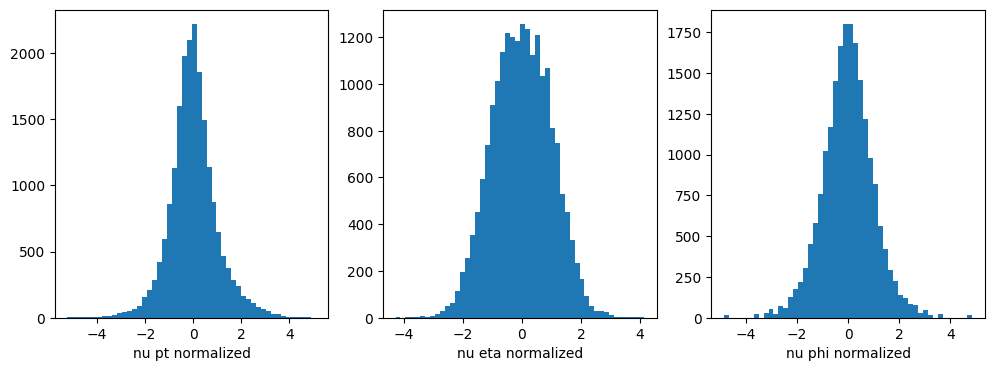

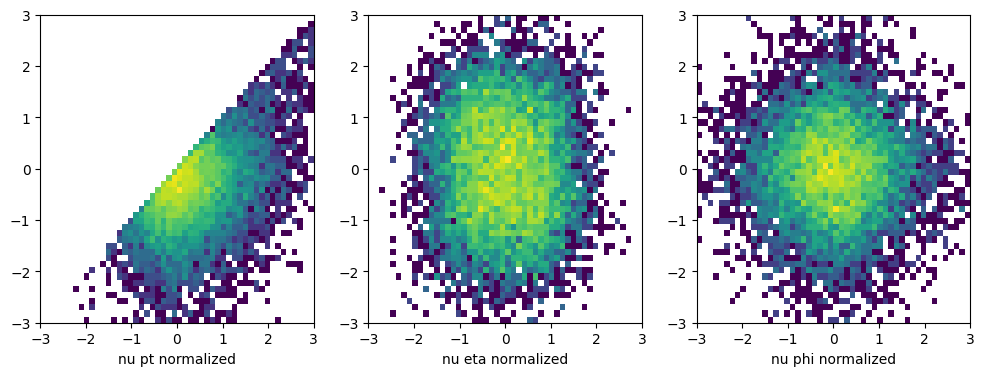

In [6]:
f, axs = plt.subplots(1, 3, figsize=(12,4))
axs[0].hist(nu.cpu().numpy()[:,:,0].flatten(), bins=50);
axs[0].set_xlabel("nu pt normalized")
axs[1].hist(nu.cpu().numpy()[:,:,1].flatten(), bins=50);
axs[1].set_xlabel("nu eta normalized")
axs[2].hist(nu.cpu().numpy()[:,:,2].flatten(), bins=50);
axs[2].set_xlabel("nu phi normalized")

f, axs = plt.subplots(1, 3, figsize=(12,4))
axs[0].hist2d(nu.cpu().numpy()[:,0,0].flatten(),
            nu.cpu().numpy()[:,1,0].flatten(), bins=50, range=((-3,3),(-3,3)), norm=LogNorm());
axs[0].set_xlabel("nu pt normalized")
axs[1].hist2d(nu.cpu().numpy()[:,0,1].flatten(),
            nu.cpu().numpy()[:,1,1].flatten(), bins=50,  range=((-3,3),(-3,3)),norm=LogNorm());
axs[1].set_xlabel("nu eta normalized")
axs[2].hist2d(nu.cpu().numpy()[:,0,2].flatten(),
            nu.cpu().numpy()[:,1,2].flatten(), bins=50,  range=((-3,3),(-3,3)), norm=LogNorm());
axs[2].set_xlabel("nu phi normalized")


# Model definition

In [7]:
class MaskedTransformer(nn.Module):
    def __init__(self, d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward=512):
        super().__init__()
        #https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html#torch.nn.Transformer
        self.transformer = Transformer(d_model=d_model,
                                       nhead=nhead,
                                       num_encoder_layers=num_encoder_layers,
                                       num_decoder_layers=num_decoder_layers,
                                       dim_feedforward=dim_feedforward,
                                       batch_first = True # Inputs will be [batch, sequence, dim]
                                      )

    def forward(self, src, tgt, src_key_padding_mask=None, tgt_key_padding_mask=None):
        output = self.transformer(src, tgt,
                                  src_key_padding_mask=src_key_padding_mask,
                                  tgt_key_padding_mask=tgt_key_padding_mask)
        return output

In [8]:
class nuRegressorComplete(nn.Module):

    def __init__(self, d_model=128, nhead=8,
                 num_encoder_layers=2,
                 num_decoder_layers=2,
                 dim_feedforward=512,
                 output_dim=3,
                 regression_net=[64,64],
                 jet_features = 4,
                 let_features = 3,
                 met_features = 2,
                 jj_features = 2,
                 max_njets= 10,
                ):
        super().__init__()
        self.d_model = d_model
        self.transformer = MaskedTransformer(d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward)

        self.embedding_jets = nn.Sequential(
            nn.Linear(jet_features, d_model-1), # -1 to account for the additional label added to the features
            nn.SELU()
        )
        self.embedding_lep = nn.Sequential(
            nn.Linear(let_features, d_model-1),
            nn.SELU()
        )
        self.embedding_met = nn.Sequential(
            nn.Linear(met_features, d_model-1),
            nn.SELU()
        )
        self.embedding_jj = nn.Sequential(
            nn.Linear(jj_features, d_model-1),
            nn.SELU()
        )

        _layers = [nn.Linear(d_model, regression_net[0]), nn.SELU()]
        for i in range(len(regression_net)-1):
            _layers.append(nn.Linear(regression_net[i], regression_net[i+1]))
            _layers.append(nn.SELU())

        _layers.append(nn.Linear(regression_net[-1], output_dim))
        self.regression_net = nn.Sequential(*_layers)

        # Technicality: temporary objects, not parameters
        self.register_buffer('obj_type', get_obj_type_tensor(max_njets))
        self.register_buffer("decoder_null_tokens", torch.zeros((2, self.d_model), dtype=torch.float32))


    def forward(self, jets, leptons, met, jj, full_mask):
        batch_size = jets.size(0)
        emb_jets = self.embedding_jets(jets)
        emb_lep = self.embedding_lep(leptons)
        emb_met = self.embedding_met(met)
        emb_jj = self.embedding_jj(jj)

        labels = self.obj_type.expand(batch_size, *list(self.obj_type.shape))

        emb = torch.cat([emb_jets, emb_lep, emb_met, emb_jj], dim=1)# [B, T1, F] concat axis1 [B, T2, F]
        emb = torch.cat([emb, labels], dim=-1)# [B, T, F1] concat axis2 [B, T, F2]

        # expanding the mask for lepton and met and jj
        tgt = self.decoder_null_tokens.expand(batch_size, *list(self.decoder_null_tokens.shape))
        out_transf = self.transformer(src=emb, tgt=tgt, src_key_padding_mask=full_mask)

        out = self.regression_net(out_transf)
        return out

## example: let's see the model summary

In [9]:
d_model = 64
nhead = 4
num_encoder_layers = 2
num_decoder_layers = 2

model = nuRegressorComplete(d_model, nhead, num_encoder_layers, num_decoder_layers,
                   regression_net=[32,32])
model.to("cuda")

nuRegressorComplete(
  (transformer): MaskedTransformer(
    (transformer): Transformer(
      (encoder): TransformerEncoder(
        (layers): ModuleList(
          (0-1): 2 x TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
            )
            (linear1): Linear(in_features=64, out_features=512, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
            (linear2): Linear(in_features=512, out_features=64, bias=True)
            (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (dropout1): Dropout(p=0.1, inplace=False)
            (dropout2): Dropout(p=0.1, inplace=False)
          )
        )
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (decoder): TransformerDecoder(
        (layers): ModuleList(
          (0

In [10]:
inputs = next(iter(dataloader_train))
jets, lepton, met, jj, full_mask, nu = inputs
nu_out = model(jets, lepton, met, jj, full_mask==0)
nu_out.shape

torch.Size([2048, 2, 3])

# Training

In [11]:
def train(model, device, loader, val_loader,  optimizer, criterion, epochs, plot=False):
    for epoch in range(epochs):
        model.train()
        for batch_idx, (jets, lepton, met, jj, full_mask, nu) in enumerate(loader):

            optimizer.zero_grad()
            nu_out = model(jets, lepton, met, jj, full_mask==0)
            # we need to convert the padding mask in the format pytorch expects
            # full_mask  ==0 --> put True to the masked value.

            loss = criterion(nu_out, nu).mean() #[B, T, F]

            if batch_idx % 100 == 0:
                print(f"epoch {epoch}, step {batch_idx}, Loss: {loss}")

            loss.backward()
            optimizer.step()

        # Validation loss
        model.eval()
        val_loss = 0.
        with torch.no_grad():
            for jets_val, lepton_val, met_val, jj_val ,full_mask_val, nu_val in val_loader:
                nu_out_val = model(jets_val, lepton_val, met_val, jj_val, full_mask_val==0)
                loss = criterion(nu_out_val, nu_val)
                val_loss += loss.nanmean().item()

#            if plot:
#                _ = validation_plots(nu_val, nu_out_val)
#                plt.show()

            val_loss = val_loss / len(val_loader)

            print(f"epoch {epoch}, validation loss: {val_loss}")
        print("End of epoch")
    return model

In [12]:
num_epochs = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

d_model = 32
nhead = 4
num_encoder_layers = 2
num_decoder_layers = 2
learning_rate = 1e-4

model = nuRegressorComplete(d_model, nhead, num_encoder_layers, num_decoder_layers,
                   regression_net=[16])
model.to(device)

print(f"Model with {count_parameters(model)} parameters")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss(reduction='none')

trained_model = train(model, device, dataloader_train, dataloader_val, optimizer, criterion, num_epochs)

Model with 160404 parameters
epoch 0, step 0, Loss: 1.0612610578536987
epoch 0, validation loss: 0.8583559036254883
End of epoch
epoch 1, step 0, Loss: 0.901566743850708
epoch 1, validation loss: 0.8203823566436768
End of epoch
epoch 2, step 0, Loss: 0.8291319608688354
epoch 2, validation loss: 0.8114765048027038
End of epoch
epoch 3, step 0, Loss: 0.8144962787628174
epoch 3, validation loss: 0.8019628643989563
End of epoch
epoch 4, step 0, Loss: 0.8116270899772644
epoch 4, validation loss: 0.7991572380065918
End of epoch
epoch 5, step 0, Loss: 0.8259961009025574
epoch 5, validation loss: 0.7977120876312256
End of epoch
epoch 6, step 0, Loss: 0.8063044548034668
epoch 6, validation loss: 0.7952994465827942
End of epoch
epoch 7, step 0, Loss: 0.808426558971405
epoch 7, validation loss: 0.7937997579574585
End of epoch
epoch 8, step 0, Loss: 0.7998670935630798
epoch 8, validation loss: 0.7920506834983826
End of epoch
epoch 9, step 0, Loss: 0.8211609125137329
epoch 9, validation loss: 0.789

# Output plots

In [13]:
def plot_samples(nu_sampl, nu_true):
    f1 , axs = plt.subplots(2, 3, figsize=(12, 8))
    for i in range(2):
        for j in range(3):
            f = plt
            axs[i][j].hist2d(nu_sampl[:,i, j], nu_true[:,i, j],
              bins=60,
            norm=LogNorm())
            if j == 0:
                axs[i][j].set_xlabel("Target pt")
                axs[i][j].set_ylabel("Regressed pt")
            elif j == 1:
                axs[i][j].set_xlabel("Target eta")
                axs[i][j].set_ylabel("Regressed eta")
            elif j == 2:
                axs[i][j].set_xlabel("Target phi")
                axs[i][j].set_ylabel("Regressed phi")
            elif j == 3:
                axs[i][j].set_xlabel("Target mass")
                axs[i][j].set_ylabel("Regressed mass")


    f2 , axs = plt.subplots(2, 3, figsize=(16, 10))
    for i in range(2):
        for j in range(3):
            f = plt
            axs[i][j].hist(nu_true[:,i, j], bins=80, range=(-3,3), label="Target", histtype="step")
            axs[i][j].hist(nu_sampl[:,i, j], bins=80, range=(-3,3), label="Regressed", histtype="step")
            axs[i][j].legend()
            if j == 0:
                axs[i][j].set_xlabel("pt")
            elif j == 1:
                axs[i][j].set_xlabel("eta")
            elif j == 2:
                axs[i][j].set_xlabel("phi")


In [14]:
model.eval()
with torch.no_grad():
    jets, lepton, met, jj, full_mask, nu = dataset_val[0:20000]
    nu_out = model(jets, lepton, met, jj, full_mask==0)
    loss = criterion(nu_out, nu)

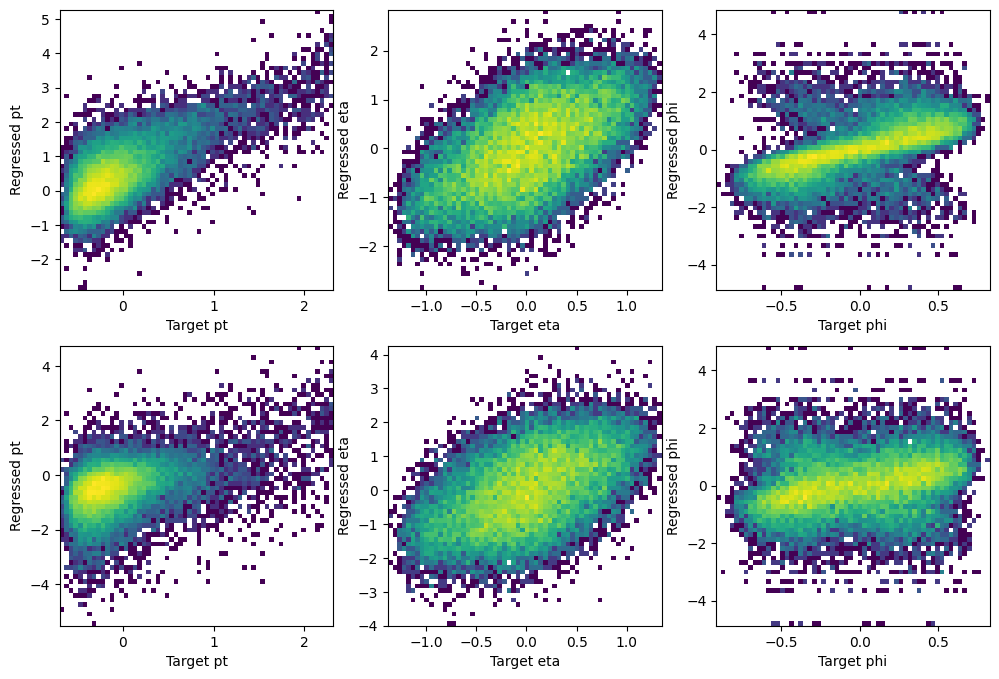

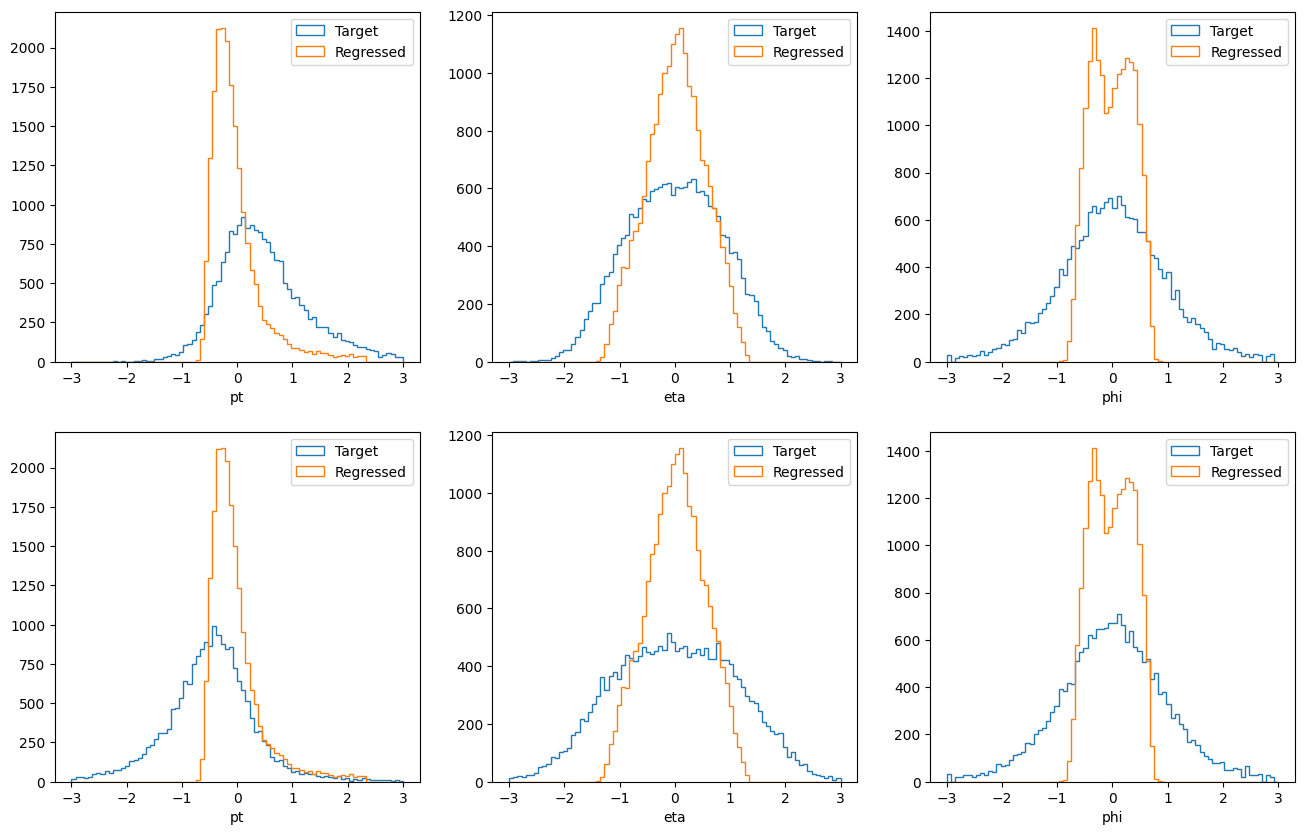

In [15]:
plot_samples(nu_out.cpu().numpy(), nu.cpu().numpy())